# Solving Lindblad equation numerically for an atom in a thermal cavity using numerical integration, a Monte-Carlo method and a vectorization approach.

The Lindbad equation describes the dynamic of the density matrix $\rho$ of an open quantum system. The effect environment is taken into account through the so calles jump operators denoted as $L_\alpha$ in the following. A general Lindblad equation is:

$$ \frac{d \rho}{dt} = - \frac{i}{\hbar} [H,\rho] + \sum_\alpha \left( L_\alpha \rho L_\alpha^\dagger - \frac{1}{2}  \{ L_\alpha^\dagger L_\alpha, \rho \} \right) $$

We consider an two-level atom inside a thermal cavity. The excited state is written as $\ket{e}$ and the ground state is $\ket{g}$. The Hamiltonian of the problem can be written $H=\frac{1}{2}\omega \sigma_z$ where $\sigma_z$ is the $Z$ Pauli matrix and $\omega$ is the difference of energy between the excited and ground states.

Inside a thermal cavity, there will be stimulated emission as well as absorption of photons.

- **Stimulated emission**: the rate of emission will depend on the number of photons present in the cavity $n$. With a few approximations the emission rate is $T(n+1)$ where $T$ is just a constant. This gives the following jump operator: $$L_-=\sqrt{T(n+1)}\sigma_-$$
where $\sigma_-=\frac{1}{2}(\sigma_x-i\sigma_y)$.

- **Absorption**: jump operator: $$L_+=\sqrt{Tn}\sigma_+$$ where $\sigma_+=\sigma_-^\dagger$

We assume $n$ large, and the environment is also large meaning the fluctuations of the number of photons are small and therefore $n$ can be fixed and equal to the thermal state value.

Thus, the Lindblad equation for a two-level atom inside a thermal cavity yields:

$$ \frac{d \rho}{dt} = -i \frac{\omega}{2} [\sigma_Z,\rho] + T(n+1) \left( \sigma_{-}\rho \sigma_{+} - \frac{1}{2}  \{ \sigma_{+}\sigma_{-}, \rho \} \right) + Tn \left( \sigma_{+}\rho \sigma_{-} - \frac{1}{2}  \{ \sigma_{-}\sigma_{+}, \rho \} \right) $$

where we denote the components of $\rho$ as such: 
$$
\rho =
\begin{pmatrix}
\rho_{ee} & \rho_{eg} \\
\rho_{ge} & \rho_{gg}
\end{pmatrix}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import *
import cmath

Let us first define some useful parameters, constants and functions that will be used throughought all this notebook:

In [ ]:
## Parameters:
# Emission rate
T=1 

# Omega
w=3 

# Thermal number of photons
n=10 

## Useful constants:
# Imaginary unit
j=complex(0,1)

# Sigma_plus
S_p=np.array([[0,1],[0,0]]) 

# Sigma_minus
S_m=np.array([[0,0],[1,0]])

# Sigma_z
S_z=np.array([[1,0],[0,-1]]) 

## Useful functions:
def commutator(A,B):
    return np.dot(A,B)-np.dot(B,A)

def anticommutator(A,B):
    return np.dot(A,B)+np.dot(B,A)

## First method: the numerical integration (RK4)

We first use the Runge-Kutta 4 method to solve the equation. This numerical method is one of the most accurate integration approach. In our case, using a simple Euler scheme is not sufficient to solve the equation, that is why RK4 is used:

c:\Users\wagne\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\wagne\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


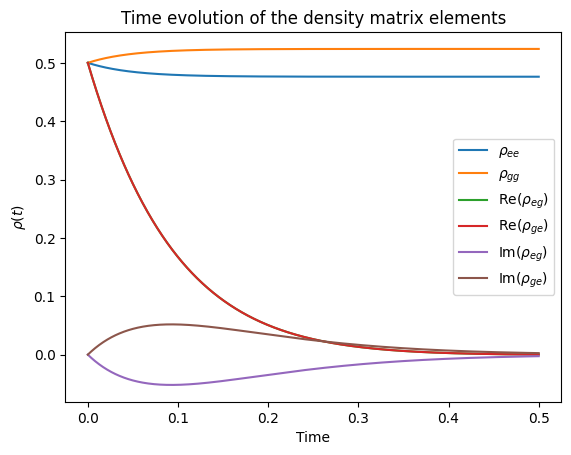

In [ ]:
## Derivative of rho according to the Lindblad equation:
def drho_dt(w,T,n,S_z,S_m,S_p,rho,i):

    return (
        -j*w/2*(commutator(S_z,rho[i-1])) 
    + T*(n+1)*(np.dot(np.dot(S_m,rho[i-1]),S_p)-1/2*anticommutator(np.dot(S_p,S_m),rho[i-1])) 
    + T*n*(np.dot(np.dot(S_p,rho[i-1]),S_m)-1/2*anticommutator(np.dot(S_m,S_p),rho[i-1]))
    )


## Initialize the time evolution:
# Time array
t=np.linspace(0,0.5,1000) 

# Array to store the density matrix at each time step
rho=np.zeros((len(t),2,2),dtype=complex) 

# Initial condition
rho[0]=1/2*np.array([[1,1],[1,1]])


## Implementing RK4 method to solve the Lindblad equation:
for i in range(1,len(t)):

    # Time step:
    dt=t[i]-t[i-1]

    # RK4 method to update the density matrix
    k1=drho_dt(w,T,n,S_z,S_m,S_p,rho,i)
    k2=drho_dt(w,T,n,S_z,S_m,S_p,rho+dt*k1/2,i)
    k3=drho_dt(w,T,n,S_z,S_m,S_p,rho+dt*k2/2,i)
    k4=drho_dt(w,T,n,S_z,S_m,S_p,rho+dt*k3,i)

    rho[i]=rho[i-1]+dt/6*(k1+2*k2+2*k3+k4) 

    
# Plotting the results:
plt.plot(t,rho[:,0,0],label=r'$\rho_{ee}$')
plt.plot(t,rho[:,1,1],label=r'$\rho_{gg}$')
plt.plot(t,rho[:,0,1].real,label=r'Re($\rho_{eg}$)')
plt.plot(t,rho[:,1,0].real,label=r'Re($\rho_{ge}$)')
plt.plot(t,rho[:,0,1].imag,label=r'Im($\rho_{eg}$)')
plt.plot(t,rho[:,1,0].imag,label=r'Im($\rho_{ge}$)')

plt.xlabel('Time')
plt.ylabel(r'$\rho(t)$')

plt.title('Time evolution of the density matrix elements')

plt.legend()

plt.show()


## Second method: quantum trajectory approach (wave function Monte Carlo):

Since the density matrix is of size $N^2$, solving the Lindblad equation for large $N$ can be demanding. The quantum trajectory approach follows the steps:

1. Start with ket $\ket{\psi(t)}$. If $t=0$ the state is given by the initial conditions. Otherwise it is the state from the previous iteration.
2. Compute $$P_\alpha=dt \bra{\psi(t)}L_\alpha^\dagger L_\alpha \ket{\psi(t)}$$ and $$P_0=1-\sum_\alpha P_\alpha$$ respectively the probability for $L_\alpha$ having happened in time step $dt$ and the probability for no quantum jump. 
3. Draw a random $r \in [0,1)$:
- if $r<P_0$: $$\ket{t+dt}=(I-i dt J)\ket{\psi(t)}$$ where $J=H-\frac{i}{2}\sum_\alpha L_\alpha^\dagger L_\alpha $ describes a damped time evolution.
- else: pick $\nu$ as the smallest index such that $$\sum_{\alpha=0}^\nu P_\alpha>r$$ and evolve $\ket{\psi}$ with: $$\ket{t+dt}=L_nu \ket{\psi(t)}$$
4. Renormalize the state $\ket{\psi(t+dt)}$


We re-iterate these steps until we reach the maximal time that we want the system to be simulated at.


### Test case: spontaneous emission of a two-level atom 

 Let us start by simulating a simpler case decay of a two-level atom in vacuum with initial condition $\ket{\psi_e}$. The dynamic of the system is governed by the following Lindblad equation:


$$ \frac{d \rho}{dt} = -i \frac{\omega}{2} [\sigma_Z,\rho] + T \left( \sigma_{-}\rho \sigma_{+} - \frac{1}{2}  \{ \sigma_{+}\sigma_{-}, \rho \} \right)  $$

and can be solved analytically:

$$
\rho(t) = \rho(0)
\begin{pmatrix}
e^{-Tt} & e^{-i \omega t - \frac{T}{2}t} \\
e^{+i \omega t - \frac{T}{2}t} & 1
\end{pmatrix}
+
\begin{pmatrix}
0 & 0 \\
0 & \rho_{ee}(0)(1-e^{-Tt})
\end{pmatrix}

$$


Therefore, we will have something to compare our numerical results with.

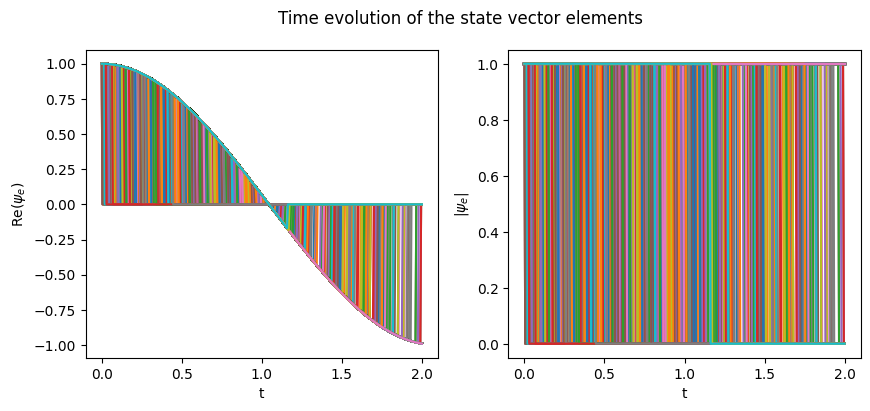

In [ ]:
## More useful constants:
# Jump operator for emission
L_m=np.sqrt(T)*S_m 

# Hermitian conjugate of L_m
L_p=np.sqrt(T)*S_p

# Identity matrix
I=np.eye(2) 

# Hamiltonian of the system
H=w/2*S_z 

# J matrix for the no-jump evolution
J=H-j/2*np.dot(L_p,L_m) 


## Initialisation:
# Number of trajectories
N=1000 

# Time array
t=np.linspace(0,2,400) 

# Initial state vector
psi_0=np.array([[1],[0]])

# List to store the state vector of each trajectory at each time step
Psi=[] 


## Monte carlo simulation of the quantum trajectories:
#Preparation of the plot:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

fig.suptitle('Time evolution of the state vector elements')

axs[0].set_xlabel('t')
axs[1].set_xlabel('t')

axs[0].set_ylabel(r'Re($\psi_e$)')
axs[1].set_ylabel(r'|$\psi_e$|')

# Iteration over the trajectories:
for k in range(N):

    # Initialisation of the state vector for the trajectory:
    # Array to store the state vector at each time step
    psi=np.zeros((len(t),2,1),dtype=complex)

    # Initial condition
    psi[0]=psi_0

    # Iteration over the time steps:
    for i in range(1,len(t)):

        # Time step
        dt=t[i]-t[i-1] 

        # Computation of the probabilities of the jumps:
        P_m=dt*np.dot(np.dot(psi[i-1].conj().T,np.dot(L_p,L_m)),psi[i-1])
        P_m=P_m[0,0].real
        P_0=1-P_m

        # Random number to decide which jump occurs
        r=np.random.rand() 

        # No-jump
        if r<P_0:
            psi[i]=np.dot((I-j*dt*J),psi[i-1])
        
        # Jump
        else: 
            psi[i]=np.dot(L_m,psi[i-1])
            
        # Normalize the state vector    
        psi[i]/=np.linalg.norm(psi[i]) 
    
    #Plotting the results:
    axs[0].plot(t, psi[:,0,0].real)

    norm = np.abs(psi[:,0,0])
    axs[1].plot(t, norm.real)

    # Store the state vector of the trajectory
    Psi.append(psi) 

plt.show()

    

Averaging to get the evolution of the matrix element $\rho_{ee}$:

$$\overline{\rho}(t)=\frac{1}{N} \sum_i \ket{\psi_i(t)} \bra{\psi_i(t)}$$

where $N$ is the number of samples and the sum is carried out on all samples $i$.

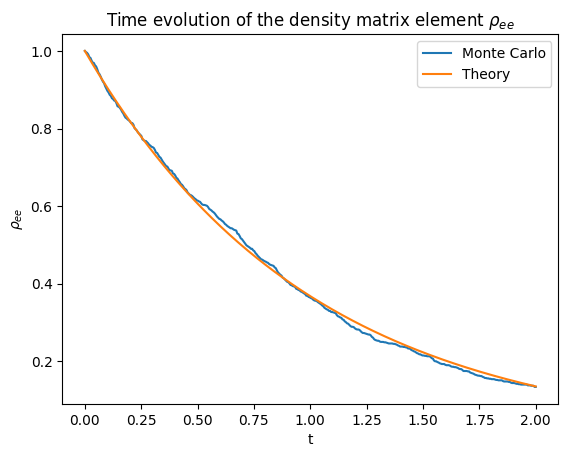

In [ ]:
# Compute density matrix for each trajectory, then average:

rho = np.zeros((len(t), 2, 2), dtype=complex)

for k in range(len(Psi)):
    for i in range(len(t)):
        rho[i] += np.dot(Psi[k][i], Psi[k][i].conj().T)

rho /= len(Psi)  # normalize by number of trajectories

#Comparison with the theoretical result:

rho_the=rho[0,0,0]*np.exp(-T*t)

#Plotting the results:

plt.plot(t,rho[:,0,0],label='Monte Carlo')
plt.plot(t,rho_the,label='Theory')
plt.xlabel('t')
plt.ylabel(r'$\rho_{ee}$')
plt.title(r'Time evolution of the density matrix element $\rho_{ee}$')
plt.legend()
plt.show()

### Case of interest: two-level atom in a thermal cavity

Now, let us compute the evolution of the density matrix of a two-level atom in a thermal cavity:

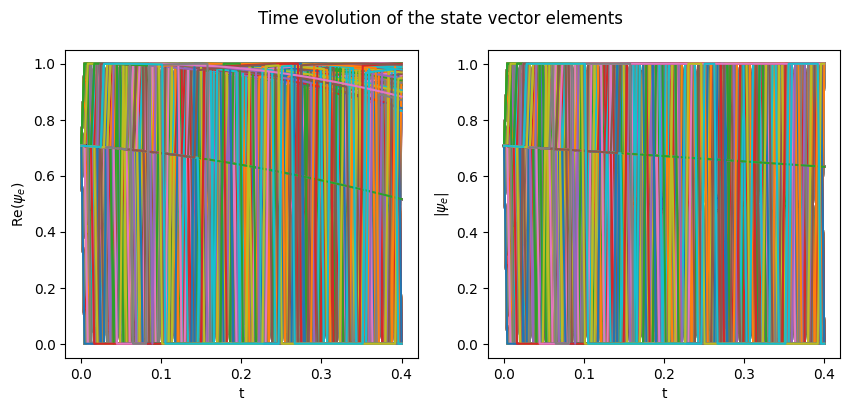

In [ ]:
## More useful constants:
# Jump operator for emission
L_m=np.sqrt(T*(n+1))*S_m 

# Jump operator for absorption
L_p=np.sqrt(T*n)*S_p 

# Identity matrix
I=np.eye(2) 

# Hamiltonian of the system
H=w/2*S_z 

# J matrix for the no-jump evolution
J=H-j/2*(np.dot(L_m.conj().T,L_m)+np.dot(L_p.conj().T,L_p)) 


## Initialisation:
# Number of trajectories
N=3000 

# Time array
t=np.linspace(0,0.4,100) 

# Initial state vector
psi_0=1/np.sqrt(2)*np.array([[1],[1]]) 

# List to store the state vector of each trajectory at each time step
Psi=[] 


## Monte carlo simulation of the quantum trajectories:
#Preparation of the plot:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

fig.suptitle('Time evolution of the state vector elements')

axs[0].set_xlabel('t')
axs[1].set_xlabel('t')

axs[0].set_ylabel(r'Re($\psi_e$)')
axs[1].set_ylabel(r'|$\psi_e$|')

#Iteration over the trajectories:
for k in range(N):

    # Array to store the state vector at each time step
    psi=np.zeros((len(t),2,1),dtype=complex) 

    # Initial condition
    psi[0]=psi_0 

    # Iteration over the time steps:
    for i in range(1,len(t)):
        # Time step
        dt=t[i]-t[i-1]


        # Probability of a jump due to L_m
        P_m=dt*np.dot(np.dot(psi[i-1].conj().T,np.dot(L_m.conj().T,L_m)),psi[i-1])
        P_m=P_m[0,0].real 

        # Probability of a jump due to L_p
        P_p=dt*np.dot(np.dot(psi[i-1].conj().T,np.dot(L_p.conj().T,L_p)),psi[i-1])
        P_p=P_p[0,0].real 

        # Probability of no jump
        P_0=1-P_m-P_p

        # Random number to decide which jump occurs
        r=np.random.rand()

        # No-jump
        if r<P_0:
            psi[i]=np.dot((I-j*dt*J),psi[i-1])

        # Jump due to L_m
        elif r<P_0+P_m:
            psi[i]=np.dot(L_m,psi[i-1])

        # Jump due to L_p  
        else:
            psi[i]=np.dot(L_p,psi[i-1])

        # Normalize the state vector
        psi[i]/=np.linalg.norm(psi[i])
    
   
    # Store the state vector of the trajectory
    Psi.append(psi) 

    #Plotting the results
    axs[0].plot(t, psi[:,0,0].real)    
    norm = np.abs(psi[:,0,0])
    axs[1].plot(t, norm.real)

plt.show()

Averaging to plot the matrix elements:

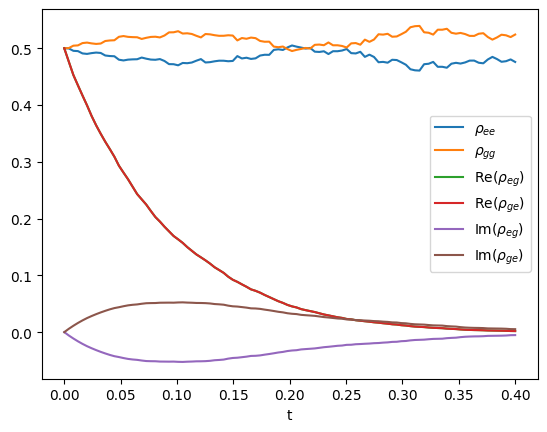

In [ ]:
# Compute density matrix for each trajectory, then average:

rho = np.zeros((len(t), 2, 2), dtype=complex)

for k in range(len(Psi)):
    for i in range(len(t)):
        rho[i] += np.dot(Psi[k][i], Psi[k][i].conj().T)

rho /= len(Psi)  # normalize by number of trajectories

#Comparison with the theoretical result:

rho_the=rho[0,0,0]*np.exp(-T*t)

#Plotting the results:

plt.plot(t,rho[:,0,0],label=r'$\rho_{ee}$')
plt.plot(t,rho[:,1,1],label=r'$\rho_{gg}$')
plt.plot(t,rho[:,0,1].real,label=r'Re($\rho_{eg}$)')
plt.plot(t,rho[:,1,0].real,label=r'Re($\rho_{ge}$)')
plt.plot(t,rho[:,0,1].imag,label=r'Im($\rho_{eg}$)')
plt.plot(t,rho[:,1,0].imag,label=r'Im($\rho_{ge}$)')
plt.xlabel('t')
plt.legend()
plt.show()

Which we compare with the curve plotted using RK4:

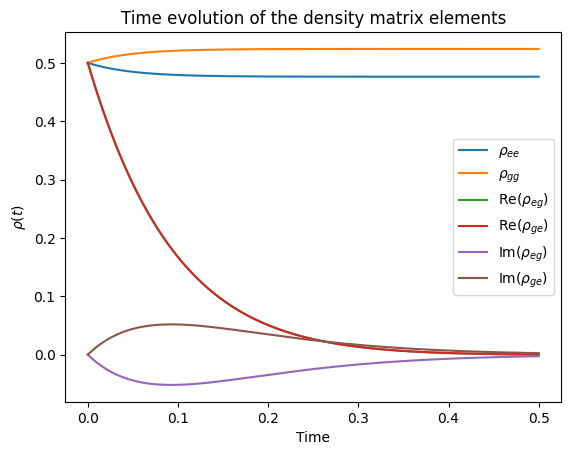

## Third method: vecotrization of the wave function

In progress